<div style="display: flex; background-color: RGB(255,114,0);" >
<h1 style="margin: auto; padding: 30px; ">ANALYSE DU STOCK ET DES VENTES DU SITE BOTTLENECK</h1>
</div>

<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 1 - Importation des librairies et chargement des fichiers</h2>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">1.1 - Importation des librairies</h3>
</div>

In [386]:
#Importation de la librairie Pandas
import pandas as pd

In [387]:
#Importation de la librairie plotly express
import plotly.express as px

In [388]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [389]:
#Trouver dans Google l'instruction permettant d'afficher toutes les colonnes d'un dataframe

#Saisir dans Google les mots clés "display all columns dataframe Pandas" par exemple.
pd.options.display.max_columns = None

# Stack Overflow indique également la formules pour afficher toutes les lignes
# pd.options.display.max_rows = None

#Dans les résultats de la recherche, privilégier les solutions provenant de Stack Overflow ou Medium

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">1.2 - Chargements des fichiers</h3>
</div>

In [390]:
#Importation du fichier web.xlsx
df_web = pd.read_excel("web.xlsx")
#Importation du fichier erp.xlsx
df_erp = pd.read_excel("erp.xlsx")
#Importation du fichier liaison.xlsx
df_liaison = pd.read_excel("liaison.xlsx")

d:\FORMATION DATA ANALYST\PROJETS OC\P6\.venv\Lib\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning:

Unknown extension is not supported and will be removed

d:\FORMATION DATA ANALYST\PROJETS OC\P6\.venv\Lib\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning:

Unknown extension is not supported and will be removed

d:\FORMATION DATA ANALYST\PROJETS OC\P6\.venv\Lib\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning:

Unknown extension is not supported and will be removed



<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 2 - Analyse exploratoire des fichiers</h2>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1 - Analyse exploratoire du fichier erp.xlsx</h3>
</div>

In [391]:
#Afficher les dimensions du dataset
print("Le tableau comporte {} observation(s) ou article(s)".format(df_erp.shape[0]))
print("Le tableau comporte {} colonne(s)".format(df_erp.shape[1]))

Le tableau comporte 825 observation(s) ou article(s)
Le tableau comporte 6 colonne(s)


In [392]:
#Consulter le nom des colonnes
print("Les colonnes du tableau ERP sont les suivantes : {}".format(df_erp.columns))

#La nature des données dans chacune des colonnes
print("La nature des données du tableau ERP est la suivante : {} ".format(df_erp.dtypes))

#Le nombre de valeurs présentes dans chacune des colonnes
df_erp.info()
df_erp.notna().sum()

Les colonnes du tableau ERP sont les suivantes : Index(['product_id', 'onsale_web', 'price', 'stock_quantity', 'stock_status',
       'purchase_price'],
      dtype='object')
La nature des données du tableau ERP est la suivante : product_id          int64
onsale_web          int64
price             float64
stock_quantity      int64
stock_status       object
purchase_price    float64
dtype: object 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 825 entries, 0 to 824
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   product_id      825 non-null    int64  
 1   onsale_web      825 non-null    int64  
 2   price           825 non-null    float64
 3   stock_quantity  825 non-null    int64  
 4   stock_status    825 non-null    object 
 5   purchase_price  825 non-null    float64
dtypes: float64(2), int64(3), object(1)
memory usage: 38.8+ KB


product_id        825
onsale_web        825
price             825
stock_quantity    825
stock_status      825
purchase_price    825
dtype: int64

In [393]:
#Afficher les 5 premières lignes de la table
df_erp.head()

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price
0,3847,1,24.2,16,instock,12.88
1,3849,1,34.3,10,instock,17.54
2,3850,1,20.8,0,outofstock,10.64
3,4032,1,14.1,26,instock,6.92
4,4039,1,46.0,3,outofstock,23.77


In [394]:
#Vérifier si il y a des lignes en doublon dans la colonne product_id
duplicates = df_erp[df_erp.duplicated()]
print(duplicates)

Empty DataFrame
Columns: [product_id, onsale_web, price, stock_quantity, stock_status, purchase_price]
Index: []


In [395]:
#Afficher les valeurs distinctes de la colonne stock_status
df_erp['stock_status'].unique()

#À quelle(s) autre(s) colonne(s) sont-elles liées ?
print('La colonne stock_status est liée à la colonne quantity et la colonne onsale_web')

La colonne stock_status est liée à la colonne quantity et la colonne onsale_web


In [396]:
# Création d'une colonne "stock_status_2"
# La valeur de cette deuxième colonne sera fonction de la valeur dans la colonne "stock_quantity"
# Si la valeur de la colonne "stock_quantity" est nulle, renseigner "outofstock" sinon mettre "instock"

df_erp['stock_status_2']=np.where(df_erp['stock_quantity'] <= 0, 'outofstock', 'instock')

In [397]:
#Vérifions que les 2 colonnes sont identiques:
#Les 2 colonnes sont strictement identiques si les valeurs de chaque ligne sont strictement identiques 2 à 2
#La comparaison de 2 colonnes peut se réaliser simplement avec l'instruction ci-dessous:
df_erp["stock_status"] == df_erp["stock_status_2"]

#Le résultat est l'affichage de True ou False pour chacune des lignes du dataset
print('Ce résultat est difficile à exploiter')

Ce résultat est difficile à exploiter


In [398]:
# Il est plus facile et exploitable d'afficher le nombre de lignes identiques ou non
(df_erp["stock_status"] == df_erp["stock_status_2"]).value_counts()

True     823
False      2
Name: count, dtype: int64

In [399]:
#Mais il est possible de synthétiser ce résultat en effectuant la somme de cette colonne:

#True vaut 1 et False 0
egalite=(df_erp["stock_status"] == df_erp["stock_status_2"]).sum()

#Nous devrions obtenir la somme de 825 qui correspond au nombre de lignes dans ce dataset
print(f'Le nombre de valeurs identiques entre les deux colonnes est de {egalite} valeurs')

Le nombre de valeurs identiques entre les deux colonnes est de 823 valeurs


In [400]:
#Si les colonnes ne sont absolument pas identiques ligne à ligne alors identifier la ligne en écart
##Dans ce cas je vous donne ce lien pour apprendre à réaliser des filtres dans Pandas:
##https://bitbucket.org/hrojas/learn-pandas/src/master/
##Lesson 3

mask = df_erp['stock_status'] != df_erp['stock_status_2']
df_diff = df_erp[mask]
print(f'Le nombre de lignes différentes entre les deux tables est de : {len(df_diff)}')
df_diff.head()

Le nombre de lignes différentes entre les deux tables est de : 2


,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,stock_status_2
4,4039,1,46.0,3,outofstock,23.77,instock
398,4885,1,18.7,0,instock,9.66,outofstock


In [401]:
# Modification des information outofstock et instock
df_erp.loc[df_erp['product_id']==4039, 'stock_status'] ='instock'
df_erp.loc[df_erp['product_id']==4885, 'stock_status'] ='outofstock'

In [402]:
# Vérification de l'absence de différences
df_erp[df_erp['stock_status'] != df_erp['stock_status_2']]

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,stock_status_2


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1.1 - Analyse exploratoire de chaque variable du fichier erp.xlsx</h3>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1.1.1 - Analyse de la variable PRIX</h3>
</div>

In [403]:
###############
## LES PRIX  ##
###############

#Vérification des prix: Y a t-il des prix non renseignés, négatifs ou nuls?
nuls=df_erp[df_erp['price']==0]
manque_prix = df_erp[df_erp['price'].isna()]
prix_negatifs = df_erp[df_erp['price'] < 0]
print('prix non renseignés :', len(manque_prix), ', prix négatifs :', len(prix_negatifs), ', prix nuls ',len(nuls))

#Afficher le ou les prix non renseignés dans la colonne "price"
print("Nombres d'articles avec un prix non renseigné: {}".format(manque_prix)) #Saisir l'instruction manquante dans la fonction format

#Afficher le prix minimum de la colonne "price"
print(f'Le prix minimum de la colonne price est : {df_erp['price'].min()}')

#Afficher le prix maximum de la colonne "price"
print(f'Le prix minimum de la colonne price est : {df_erp['price'].max()}')

#Afficher les prix inférieurs à 0 (qu'est-ce qu'il faut en faire ?)
print("Nombres d'articles avec un prix inferieur à zéro : {}".format(prix_negatifs)) #Saisir l'instruction manquante dans la fonction format

prix non renseignés : 0 , prix négatifs : 3 , prix nuls  0
Nombres d'articles avec un prix non renseigné: Empty DataFrame
Columns: [product_id, onsale_web, price, stock_quantity, stock_status, purchase_price, stock_status_2]
Index: []
Le prix minimum de la colonne price est : -20.0
Le prix minimum de la colonne price est : 225.0
Nombres d'articles avec un prix inferieur à zéro :      product_id  onsale_web  price  stock_quantity stock_status  \
151        4233           0  -20.0               0   outofstock   
469        5017           0   -8.0               0   outofstock   
739        6594           0   -9.1              19      instock   

     purchase_price stock_status_2  
151           10.33     outofstock  
469            4.34     outofstock  
739            4.61        instock  


In [404]:
#  A mon sens, il vaut mieux garder les données mais passer le produit en outofstock jusqu'au prochain inventaire
df_erp.loc[df_erp['price'] <= 0, 'stock_status'] ='outofstock'

In [405]:
# Vérification du fait que les prix négatifs sont passés en outofstock jusqu'au prochain inventaire
df_erp[df_erp['price'] < 0]

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,stock_status_2
151,4233,0,-20.0,0,outofstock,10.33,outofstock
469,5017,0,-8.0,0,outofstock,4.34,outofstock
739,6594,0,-9.1,19,outofstock,4.61,instock


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1.1.2 - Analyse de la variable STOCK</h3>
</div>

In [406]:
#######################
### stock_quantity  ###
#######################

#Vérification de la colonne stock quantity 
display((df_erp['stock_quantity'] < 0).value_counts())

#Afficher la quantité minimum de la colonne "stock_quantity"
print(f'La quantité minimum de la colonne stock_quantity est : {df_erp['stock_quantity'].min()}')

#Afficher la quantité maximum de la colonne "stock_quantity"
print(f'La quantité maximum de la colonne stock_quantity est : {df_erp['stock_quantity'].max()}')

#Afficher les stocks inférieurs à 0 (qu'est-ce qu'il faut en faire ?)
stocks_negatifs=df_erp[df_erp['stock_quantity'] < 0]
display(stocks_negatifs)

stock_quantity
False    823
True       2
Name: count, dtype: int64

La quantité minimum de la colonne stock_quantity est : -10
La quantité maximum de la colonne stock_quantity est : 145


,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,stock_status_2
449,4973,0,10.0,-10,outofstock,4.96,outofstock
573,5700,1,44.5,-1,outofstock,22.30,outofstock


In [407]:
# j'ai souhaité les passer en onsale_web=0 jusqu'au prochain inventaire
df_erp.loc[df_erp['product_id']==5700,'onsale_web']=0

# Attention il faut faire remonter les infos au service concerné
df_erp[df_erp['product_id'] == 5700]

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,stock_status_2
573,5700,0,44.5,-1,outofstock,22.3,outofstock


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1.1.3 - Analyse de la variable ONSALE_WEB</h3>
</div>

In [408]:
#Vérification de la colonne onsale_web et des valeurs qu'elle contient. Que signifient-elles?
display((df_erp['onsale_web']).value_counts())

#Afficher la quantité minimum de la colonne "onsale_web"
print(f'La quantité minimum de la colonne onsale_web est : {df_erp['onsale_web'].min()}')

#Afficher la quantité maximum de la colonne "onsale_web"
print(f'La quantité maximum de la colonne onsale_web est : {df_erp['onsale_web'].max()}')

# Il n'y a pas de valeurs négatives en quantité de biens en vente sur le site. Et le maximum est de 1
# Onsale_web = produit en vente ou non --> 0=pas vendu sur le site // 1=vendu sur le site

onsale_web
1    715
0    110
Name: count, dtype: int64

La quantité minimum de la colonne onsale_web est : 0
La quantité maximum de la colonne onsale_web est : 1


In [409]:
#Quelles sont les colonnes à conserver selon vous?
# COLONNES A CONSERVER : product_id	/ onsale_web / price / stock_quantity /	stock_status /	purchase_price

In [410]:
#Supprimer la colonne comportant le libellé "stock_status_2" car elle est redondante avec la colonne "stock_status".
del df_erp['stock_status_2']
df_erp.head()

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price
0,3847,1,24.2,16,instock,12.88
1,3849,1,34.3,10,instock,17.54
2,3850,1,20.8,0,outofstock,10.64
3,4032,1,14.1,26,instock,6.92
4,4039,1,46.0,3,instock,23.77


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1.1.4 - Analyse de la variable prix d'achat</h3>
</div>

In [411]:
######################
##   prix d'achat   ##
######################

#Vérification de la colonne purchase_price : 
print(f'Le nombre de produits ayant un prix d\'achat inférieur ou égal à zéro est de : {(df_erp['purchase_price'] <= 0).sum()}')

#Afficher le ou les prix non renseignés dans la colonne "purchase_price"
print(f'Le nombre de produits dont le "purchase price" n\'est pas renseigné est de : {(df_erp['purchase_price'].isna()).sum()}')

#Afficher le prix minimum de la colonne "purchase_price"
print(f'Le prix minimum de la colonne purchase_price est : {df_erp['purchase_price'].min()} €')

#Afficher le prix maximum de la colonne "purchase_price"
print(f'Le prix maximum de la colonne purchase_price est : {df_erp['purchase_price'].max()} €')

Le nombre de produits ayant un prix d'achat inférieur ou égal à zéro est de : 0
Le nombre de produits dont le "purchase price" n'est pas renseigné est de : 0
Le prix minimum de la colonne purchase_price est : 2.74 €
Le prix maximum de la colonne purchase_price est : 137.81 €


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.2 - Analyse exploratoire du fichier web.xlsx</h3>
</div>
 

In [412]:
#Dimension du dataset
#Afficher les dimensions du dataset
print("Le tableau comporte {} observation(s) ou article(s)".format(df_web.shape[0]))

print("Le tableau comporte {} colonne(s)".format(df_web.columns))

Le tableau comporte 1513 observation(s) ou article(s)
Le tableau comporte Index(['sku', 'virtual', 'downloadable', 'rating_count', 'average_rating',
       'total_sales', 'tax_status', 'tax_class', 'post_author', 'post_date',
       'post_date_gmt', 'post_content', 'product_type', 'post_title',
       'post_excerpt', 'post_status', 'comment_status', 'ping_status',
       'post_password', 'post_name', 'post_modified', 'post_modified_gmt',
       'post_content_filtered', 'post_parent', 'guid', 'menu_order',
       'post_type', 'post_mime_type', 'comment_count'],
      dtype='object') colonne(s)


In [413]:
#Consulter le nombre de colonnes
print("Le tableau comporte {} colonne(s)".format(df_web.shape[1]))

#La nature des données dans chacune des colonnes et Le nombre de valeurs présentes dans chacune des colonnes
df_web.info()

Le tableau comporte 29 colonne(s)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1513 entries, 0 to 1512
Data columns (total 29 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   sku                    1428 non-null   object        
 1   virtual                1513 non-null   int64         
 2   downloadable           1513 non-null   int64         
 3   rating_count           1513 non-null   int64         
 4   average_rating         1430 non-null   float64       
 5   total_sales            1430 non-null   float64       
 6   tax_status             716 non-null    object        
 7   tax_class              0 non-null      float64       
 8   post_author            1430 non-null   float64       
 9   post_date              1430 non-null   datetime64[ns]
 10  post_date_gmt          1430 non-null   datetime64[ns]
 11  post_content           0 non-null      float64       
 12  product_type           1429 

In [414]:
#Selon vous, quelles sont les colonnes à conserver ?
df_web.describe()

############### je garde ###############
# sku                   
# total_sales
# tax_status
# post_date
# product_type
# post_title                     
# post_name
# post_modified_gmt
# post_type

############### je ne garde pas ###############

# virtual	            
# downloadable
# rating_count
# average_rating
# tax_class
# post_author
# post_date_gmt
# post_content                
# post_status       
# comment_status       
# ping_status   
# post_excerpt
# post_password 
# post_modified
# guid
# post_content_filtered
# post_parent 
# menu_order
# comment_count
# post_mime_type

,virtual,downloadable,rating_count,average_rating,total_sales,tax_class,post_author,post_date,post_date_gmt,post_content,post_password,post_modified,post_modified_gmt,post_content_filtered,post_parent,menu_order,comment_count
count,1513.0,1513.0,1513.0,1430.0,1430.000000,0.0,1430.000000,1430,1430,0.0,0.0,1430,1430,0.0,1430.0,1430.0,1430.0
mean,0.0,0.0,0.0,0.0,8.223077,NaN,1.998601,2018-08-22 03:22:17.090909184,2018-08-22 01:53:30.097902080,NaN,NaN,2020-06-20 13:59:29.781818112,2020-06-20 12:06:02.509090816,NaN,0.0,0.0,0.0
min,0.0,0.0,0.0,0.0,-56.000000,NaN,1.000000,2018-02-08 12:58:52,2018-02-08 11:58:52,NaN,NaN,2018-02-20 15:19:23,2018-02-20 14:19:23,NaN,0.0,0.0,0.0
25%,0.0,0.0,0.0,0.0,5.000000,NaN,2.000000,2018-02-27 20:01:12.500000,2018-02-27 19:01:12.500000,NaN,NaN,2020-06-18 10:45:05.249999872,2020-06-18 08:45:05.249999872,NaN,0.0,0.0,0.0
50%,0.0,0.0,0.0,0.0,8.000000,NaN,2.000000,2018-04-19 14:56:05,2018-04-19 12:56:05,NaN,NaN,2020-08-04 09:30:06,2020-08-04 07:30:06,NaN,0.0,0.0,0.0
75%,0.0,0.0,0.0,0.0,11.000000,NaN,2.000000,2019-01-31 14:35:47,2019-01-31 13:35:47,NaN,NaN,2020-08-25 10:32:32,2020-08-25 08:32:32,NaN,0.0,0.0,0.0
max,0.0,0.0,0.0,0.0,122.000000,NaN,2.000000,2020-07-20 11:00:00,2020-07-20 09:00:00,NaN,NaN,2020-08-27 18:55:03,2020-08-27 16:55:03,NaN,0.0,0.0,0.0
std,0.0,0.0,0.0,0.0,6.721899,NaN,0.037385,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0


In [415]:
#Si vous avez défini des colonnes à supprimer, effectuer l'opération
print('j\'ai fait le choix de ne pas écraser le fichier initial qui contenait d\'autres informations, possiblement utiles pour d\'autres corps de métier. A voir ensemble si on modifie définitivement le fichier initial ou non')
df_web_copy= df_web.drop(['virtual','downloadable','rating_count','average_rating','tax_class','guid','post_author','post_date_gmt','post_excerpt','post_content', 'post_status', 'comment_status' , 'ping_status', 'post_password','post_modified','post_content_filtered','post_parent','menu_order','comment_count','post_mime_type'], axis=1)

j'ai fait le choix de ne pas écraser le fichier initial qui contenait d'autres informations, possiblement utiles pour d'autres corps de métier. A voir ensemble si on modifie définitivement le fichier initial ou non


In [416]:
# Vérification du contenu nouveau tableau df_web_copy 
df_web_copy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1513 entries, 0 to 1512
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   sku                1428 non-null   object        
 1   total_sales        1430 non-null   float64       
 2   tax_status         716 non-null    object        
 3   post_date          1430 non-null   datetime64[ns]
 4   product_type       1429 non-null   object        
 5   post_title         1430 non-null   object        
 6   post_name          1430 non-null   object        
 7   post_modified_gmt  1430 non-null   datetime64[ns]
 8   post_type          1430 non-null   object        
dtypes: datetime64[ns](2), float64(1), object(6)
memory usage: 106.5+ KB


In [417]:
############# visualisation df_web_copy
df_web_copy.head()

,sku,total_sales,tax_status,post_date,product_type,post_title,post_name,post_modified_gmt,post_type
0,11862,3.0,NaN,2018-02-12 13:46:23,Vin,Gilles Robin Hermitage Rouge 2012,gilles-robin-hermitage-2012,2019-01-31 11:12:56,attachment
1,16057,5.0,NaN,2018-04-17 15:29:17,Vin,Domaine Pellé Sancerre Rouge La Croix Au Garde...,pelle-sancerre-rouge-la-croix-au-garde-2017,2020-07-07 08:05:02,attachment
2,14692,5.0,taxable,2019-03-19 10:06:47,Vin,Château Fonréaud Bordeaux Blanc Le Cygne 2016,fonreaud-bordeaux-blanc-le-cygne-2016,2020-04-25 19:40:31,product
3,16295,14.0,NaN,2018-02-15 14:05:06,Vin,Moulin de Gassac IGP Pays d'Hérault Guilhem Ro...,moulin-de-gassac-igp-pays-dherault-guilhem-ros...,2020-08-27 16:55:03,attachment
4,15328,2.0,taxable,2019-03-27 18:05:09,Vin,Agnès Levet Côte Rôtie Maestria 2017,agnes-levet-cote-rotie-maestria-2017,2020-07-25 13:45:02,product


In [418]:
#Visualisation des valeurs de la colonne sku
print(df_web_copy['sku'].unique())

[11862 16057 14692 16295 15328 15471 16515 16246 nan 13572 16513 16585
 16269 15526 12869 15575 11586 14338 15425 16560 15361 13809 11587 15022
 14323 16342 16029 15475 13754 14680 15875 9636 13849 13662 16564 13557
 15429 14712 15032 15481 15448 16580 15441 804 15300 13958 16071 15678
 13895 15711 12882 16053 13766 16247 12640 15292 15476 15670 16189 16038
 14864 16044 15324 15531 15953 15413 15733 14366 15895 15892 16472 15185
 16010 15793 15849 12315 15741 15934 15148 15781 15659 15106 15490 14507
 14149 16307 13736 14090 16037 15758 14661 12587 15337 15489 15201 16305
 16131 13435 15747 12203 14509 14768 16262 14561 16505 15717 16129 13460
 15871 15940 11602 13127 13520 15480 13032 15436 15269 15910 19821 16263
 15138 15146 15126 15482 16186 13905 16540 15856 15677 14700 15325 19815
 3506 16056 14975 15341 15204 15415 16065 15479 16151 15127 15140 15779
 15473 15530 14805 14106 9937 15281 16553 15315 15668 13211 15161 11258
 16296 12588 15792 15921 15690 15775 15577 15870 802 15163

In [419]:
#Quelles sont les valeurs qui ne semblent pas respecter la règle de codification?

# Lecture des données inverses en utilisant un REGEX large et les valeurs non nulles
lignes_erronnees = df_web_copy[(~df_web_copy['sku'].astype(str).str.match(r'^\d{3,6}$')) & (df_web_copy['sku'].notna())] 

#Si vous avez identifié des codes articles ne respectant pas la règle de codification, consultez-les
lignes_erronnees.head(20)

,sku,total_sales,tax_status,post_date,product_type,post_title,post_name,post_modified_gmt,post_type
272,13127-1,4.0,taxable,2020-06-09 15:42:04,Vin,Clos du Mont-Olivet Châteauneuf-du-Pape 2007,clos-du-mont-olivet-chateauneuf-du-pape-2007-2,2020-07-20 15:09:06,product
458,38,10.0,NaN,2018-04-18 12:25:58,Vin,Emile Boeckel Crémant Brut Blanc de Blancs,emile-boeckel-cremant-brut-blanc-de-blancs,2020-08-27 15:15:03,attachment
842,bon-cadeau-25-euros,7.0,NaN,2018-06-01 13:53:46,Autre,Bon cadeau de 25€,bon-cadeau-de-25-euros,2018-06-01 12:13:57,attachment
964,38,10.0,taxable,2018-04-18 12:25:58,Vin,Emile Boeckel Crémant Brut Blanc de Blancs,emile-boeckel-cremant-brut-blanc-de-blancs,2020-08-27 15:15:03,product
965,41,6.0,taxable,2018-04-14 12:01:43,Vin,Marcel Windholtz Eau de Vie de Marc de Gewurzt...,marcel-windholtz-eau-de-marc-de-gewurztraminer,2020-08-03 08:25:02,product
1117,13127-1,4.0,NaN,2020-06-09 15:42:04,Vin,Clos du Mont-Olivet Châteauneuf-du-Pape 2007,clos-du-mont-olivet-chateauneuf-du-pape-2007-2,2020-07-20 15:09:06,attachment
1127,41,6.0,NaN,2018-04-14 12:01:43,Vin,Marcel Windholtz Eau de Vie de Marc de Gewurzt...,marcel-windholtz-eau-de-marc-de-gewurztraminer,2020-08-03 08:25:02,attachment
1387,bon-cadeau-25-euros,7.0,taxable,2018-06-01 13:53:46,NaN,Bon cadeau de 25€,bon-cadeau-de-25-euros,2018-06-01 12:13:57,product


In [420]:
#Identifier les lignes sans code article

# Quantité de lignes sans code
erreur_code_nan=df_web_copy[df_web_copy['sku'].isna()]
print(f'Le nombre de valeurs nulles dans la colonne est de : {df_web_copy['sku'].isna().sum()}')

# Visualisation des lignes sans code
display(erreur_code_nan)

Le nombre de valeurs nulles dans la colonne est de : 85


,sku,total_sales,tax_status,post_date,product_type,post_title,post_name,post_modified_gmt,post_type
8,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaT,NaN
20,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaT,NaN
30,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaT,NaN
37,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaT,NaN
41,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaT,NaN
...,...,...,...,...,...,...,...,...,...
1384,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaT,NaN
1429,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaT,NaN
1432,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaT,NaN
1445,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaT,NaN


In [421]:
#Pour les codes articles identifiés, réalisez une analyse et définir l'action à entreprendre
print('Je décide de supprimer les lignes sans code article. \n Toutefois je fais remonter le problème concernant ces deux produits : \n - Pierre Jean Villa Condrieu Jardin Suspendu 2018 (-56 ventes) \n - Pierre Jean Villa Côte Rôtie Fongeant 2017 (-17 ventes)')

Je décide de supprimer les lignes sans code article. 
 Toutefois je fais remonter le problème concernant ces deux produits : 
 - Pierre Jean Villa Condrieu Jardin Suspendu 2018 (-56 ventes) 
 - Pierre Jean Villa Côte Rôtie Fongeant 2017 (-17 ventes)


In [422]:
#La clé pour chaque ligne est-elle unique? autrement dit, y a-t-il des doublons?
doublons=df_web_copy['sku'].duplicated().sum()
print(f'Le nombre de valeurs en double est de : {doublons} valeurs')

print('Je décide de supprimer les doublons')

Le nombre de valeurs en double est de : 798 valeurs
Je décide de supprimer les doublons


In [423]:
#Les lignes sans code article semblent être toutes non renseignées

#Pour s'en assurer, réaliser les étapes suivantes:

#1 - Créer un dataframe avec uniquement les lignes sans code article
df_vide=df_web_copy[df_web_copy['sku'].isna()]

#2 - Utiliser la fonction df.info() sur ce nouveau dataframe pour observer le nombre de valeurs renseignées dans chacune des colonnes
df_vide.info()

# Affichage des lignes n'étant pas totalement vides
lignes_non_vides = df_vide[df_vide.notna().any(axis=1)]
display(lignes_non_vides)

#3 - Que constatez-vous? 
print('Le dataframe ne comprend presque que des données vides, de ce fait, je les supprime')
df_web_copy.dropna(subset=['sku'], inplace=True)

<class 'pandas.core.frame.DataFrame'>
Index: 85 entries, 8 to 1457
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   sku                0 non-null      object        
 1   total_sales        2 non-null      float64       
 2   tax_status         2 non-null      object        
 3   post_date          2 non-null      datetime64[ns]
 4   product_type       2 non-null      object        
 5   post_title         2 non-null      object        
 6   post_name          2 non-null      object        
 7   post_modified_gmt  2 non-null      datetime64[ns]
 8   post_type          2 non-null      object        
dtypes: datetime64[ns](2), float64(1), object(6)
memory usage: 6.6+ KB


,sku,total_sales,tax_status,post_date,product_type,post_title,post_name,post_modified_gmt,post_type
1084,NaN,-56.0,taxable,2018-08-08 11:23:43,Vin,Pierre Jean Villa Condrieu Jardin Suspendu 2018,pierre-jean-villa-condrieu-suspendu-2018,2019-11-02 12:24:01,product
1087,NaN,-17.0,taxable,2018-07-31 12:07:23,Vin,Pierre Jean Villa Côte Rôtie Fongeant 2017,pierre-jean-villa-cote-rotie-fongeant-2017,2019-11-02 12:24:15,product


Le dataframe ne comprend presque que des données vides, de ce fait, je les supprime


In [424]:
# Vérification de la bonne réalisation de l'action
df_web_copy.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1428 entries, 0 to 1512
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   sku                1428 non-null   object        
 1   total_sales        1428 non-null   float64       
 2   tax_status         714 non-null    object        
 3   post_date          1428 non-null   datetime64[ns]
 4   product_type       1427 non-null   object        
 5   post_title         1428 non-null   object        
 6   post_name          1428 non-null   object        
 7   post_modified_gmt  1428 non-null   datetime64[ns]
 8   post_type          1428 non-null   object        
dtypes: datetime64[ns](2), float64(1), object(6)
memory usage: 111.6+ KB


In [425]:
# Indique les sku en doublon avec mention du post_type pour chacun
df_web_copy[df_web_copy.duplicated(subset=['sku'], keep=False)][['sku','post_type']]


,sku,post_type
0,11862,attachment
1,16057,attachment
2,14692,product
3,16295,attachment
4,15328,product
...,...,...
1508,16326,product
1509,15662,product
1510,15329,attachment
1511,14827,attachment


In [426]:
# Suppression des doublons qui correspondent à product pour l'un et attachement pour l'autre
df_web_copy = df_web_copy[df_web_copy['post_type'] == 'product']

#  Ne conserve que les doublons éventuels de post_type=product
df_web_copy=(df_web_copy.drop_duplicates(subset=['sku']))
df_web_copy.info()

<class 'pandas.core.frame.DataFrame'>
Index: 714 entries, 2 to 1509
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   sku                714 non-null    object        
 1   total_sales        714 non-null    float64       
 2   tax_status         714 non-null    object        
 3   post_date          714 non-null    datetime64[ns]
 4   product_type       713 non-null    object        
 5   post_title         714 non-null    object        
 6   post_name          714 non-null    object        
 7   post_modified_gmt  714 non-null    datetime64[ns]
 8   post_type          714 non-null    object        
dtypes: datetime64[ns](2), float64(1), object(6)
memory usage: 55.8+ KB


In [427]:
# Vérification de l'absence de doublons
df_web_copy['sku'].duplicated().sum()

np.int64(0)

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.3 - Analyse exploratoire du fichier liaison.xlsx</h3>
</div>

In [428]:
#Dimension du dataset et Nombre d'observations
print("Le tableau comporte {} observation(s) ou article(s)".format(df_liaison.shape[0]))
print("Le tableau comporte {} colonne(s)".format(df_liaison.shape[1]))

Le tableau comporte 825 observation(s) ou article(s)
Le tableau comporte 2 colonne(s)


In [429]:
#Consulter le nombre de colonnes
print("Les colonnes du tableau liaison sont les suivantes : {}".format(df_liaison.columns))

#La nature des données dans chacune des colonnes
print("La nature des données du tableau liaison la suivante : {} ".format(df_liaison.dtypes))

#Le nombre de valeurs présentes dans chacune des colonnes
df_liaison.info()
df_liaison.notna().sum()

Les colonnes du tableau liaison sont les suivantes : Index(['id_web', 'product_id'], dtype='object')
La nature des données du tableau liaison la suivante : id_web        object
product_id     int64
dtype: object 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 825 entries, 0 to 824
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   id_web      734 non-null    object
 1   product_id  825 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 13.0+ KB


id_web        734
product_id    825
dtype: int64

In [430]:
#Vérifier si il y a des lignes en doublon
duplicates_liaison = df_liaison[df_liaison.duplicated()]
print(duplicates_liaison.sum())

id_web        0
product_id    0
dtype: object


In [431]:
#Les valeurs de la colonne "product_id" sont-elles toutes uniques?
doublons_liaison_pdt=df_liaison['product_id'].duplicated().sum()
print(f'Le nombre de valeurs en double est de : {doublons_liaison_pdt}')

Le nombre de valeurs en double est de : 0


In [432]:
#Les valeurs de la colonne "id_web" sont-elles toutes uniques?
doublons_liaison_id=df_liaison['id_web'].duplicated().sum()
print(f'Le nombre de valeurs en double est de : {doublons_liaison_id}')

Le nombre de valeurs en double est de : 90


In [433]:
# #Avons-nous des articles sans correspondance?  id_web ABSENTS de product_id 
nb_non_correspondance_id = (df_liaison[df_liaison['id_web'].isin(df_liaison['product_id'])]).value_counts()
print(f"Il y a {len(nb_non_correspondance_id)} articles sans correspondance")

Il y a 3 articles sans correspondance


<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 3 - Jonction des fichiers</h2>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 3.1 - Jonction du fichier df_erp et df_liaison</h3>
</div>

In [434]:
#Fusion des fichiers df_erp et df_liaison 
df_merge=pd.merge(df_erp, df_liaison, on='product_id', how='outer', indicator=True)
print('Récupération de l\'ensemble des données des deux fichiers pour s\'assurer de ne pas perdre de correspondance éventuelle lors du merge avec df_web_copy')

Récupération de l'ensemble des données des deux fichiers pour s'assurer de ne pas perdre de correspondance éventuelle lors du merge avec df_web_copy


In [435]:
#Y a t-il des lignes ne "matchant" pas entre les 2 fichiers?  
nuls=df_merge.isna().sum()
display(nuls)
print('Il y a 91 lignes sans correspondance')

product_id         0
onsale_web         0
price              0
stock_quantity     0
stock_status       0
purchase_price     0
id_web            91
_merge             0
dtype: int64

Il y a 91 lignes sans correspondance


In [436]:
df_merge.head(15)

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,id_web,_merge
0,3847,1,24.2,16,instock,12.88,15298,both
1,3849,1,34.3,10,instock,17.54,15296,both
2,3850,1,20.8,0,outofstock,10.64,15300,both
3,4032,1,14.1,26,instock,6.92,19814,both
4,4039,1,46.0,3,instock,23.77,19815,both
5,4040,1,34.3,12,instock,18.25,15303,both
6,4041,1,32.7,12,instock,17.57,14975,both
7,4042,1,31.2,15,instock,15.48,16042,both
8,4043,1,60.0,0,outofstock,29.45,14980,both
9,4045,1,42.6,5,instock,22.01,16041,both


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 3.2 - Jonction du fichier df_merge et df_web</h3>
</div>

In [437]:
#Fusionner les datasets df_merge et df_web // Choix de faire le merge sur df_web_copy
df_merge=pd.merge(df_merge, df_web_copy, left_on='id_web', right_on='sku', how='inner')
print('J\'ai fait le choix de prendre l\'ensemble des données communes au deux fichiers')

J'ai fait le choix de prendre l'ensemble des données communes au deux fichiers


In [438]:
df_web_copy.head()

,sku,total_sales,tax_status,post_date,product_type,post_title,post_name,post_modified_gmt,post_type
2,14692,5.0,taxable,2019-03-19 10:06:47,Vin,Château Fonréaud Bordeaux Blanc Le Cygne 2016,fonreaud-bordeaux-blanc-le-cygne-2016,2020-04-25 19:40:31,product
4,15328,2.0,taxable,2019-03-27 18:05:09,Vin,Agnès Levet Côte Rôtie Maestria 2017,agnes-levet-cote-rotie-maestria-2017,2020-07-25 13:45:02,product
6,16515,10.0,taxable,2018-06-02 09:31:31,Vin,Château Turcaud Bordeaux Rouge Cuvée Majeure 2018,chateau-turcaud-bordeaux-rouge-cuvee-majeure-2018,2020-08-27 08:11:12,product
11,16585,15.0,taxable,2018-02-16 14:03:16,Vin,Xavier Frissant Touraine Sauvignon 2019,xavier-frissant-touraine-sauvignon-2019,2020-08-27 07:30:36,product
14,12869,7.0,taxable,2019-03-28 14:29:35,Vin,Stéphane Tissot Arbois D.D. 2016,stephane-tissot-arbois-dd-2016,2019-12-13 14:40:01,product


In [439]:
#Avons-nous des lignes sans correspondance?
##### Vérification des éventuelles incohérences lors du merge
mask = df_merge['_merge'] != "both"
display(df_merge[mask])

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,id_web,_merge,sku,total_sales,tax_status,post_date,product_type,post_title,post_name,post_modified_gmt,post_type


In [440]:
# Vérification de l'absence de cellules vides
df_merge[df_merge['sku'].isna()]

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,id_web,_merge,sku,total_sales,tax_status,post_date,product_type,post_title,post_name,post_modified_gmt,post_type


In [441]:
# Vérification du contenu du DF
df_merge.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 714 entries, 0 to 713
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   product_id         714 non-null    int64         
 1   onsale_web         714 non-null    int64         
 2   price              714 non-null    float64       
 3   stock_quantity     714 non-null    int64         
 4   stock_status       714 non-null    object        
 5   purchase_price     714 non-null    float64       
 6   id_web             714 non-null    object        
 7   _merge             714 non-null    category      
 8   sku                714 non-null    object        
 9   total_sales        714 non-null    float64       
 10  tax_status         714 non-null    object        
 11  post_date          714 non-null    datetime64[ns]
 12  product_type       713 non-null    object        
 13  post_title         714 non-null    object        
 14  post_name 

In [442]:
# Vérification complémentaire concernant les différents types de produits
df_merge['product_type'].unique()

array(['Vin', 'Champagne', 'Whisky', 'Cognac', nan, "Huile d'olive",
       'Gin'], dtype=object)

In [443]:
print(f'Le nombre de produits de type Champagne est de : {df_merge['product_type'].eq('Champagne').sum()}')
print(f'Le nombre de produits de type Vin est de : {df_merge['product_type'].eq('Vin').sum()}')
print(f'Le nombre de produits de type Whisky est de : {df_merge['product_type'].eq('Whisky').sum()}')
print(f'Le nombre de produits de type Cognac est de : {df_merge['product_type'].eq('Cognac').sum()}')
print(f'Le nombre de produits de type Gin est de : {df_merge['product_type'].eq('Gin').sum()}')
print(f'Le nombre de produits de type Huile d\'olive est de : {df_merge['product_type'].eq('Huile d\'olive').sum()}')
print(f'Le nombre de produits n\'ayant pas de type mentionné est de : {df_merge['product_type'].isna().sum()}')
df_merge[df_merge['product_type'].isna()]


Le nombre de produits de type Champagne est de : 28
Le nombre de produits de type Vin est de : 658
Le nombre de produits de type Whisky est de : 14
Le nombre de produits de type Cognac est de : 8
Le nombre de produits de type Gin est de : 2
Le nombre de produits de type Huile d'olive est de : 3
Le nombre de produits n'ayant pas de type mentionné est de : 1


,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,id_web,_merge,sku,total_sales,tax_status,post_date,product_type,post_title,post_name,post_modified_gmt,post_type
410,4954,1,25.0,23,instock,13.3,bon-cadeau-25-euros,both,bon-cadeau-25-euros,7.0,taxable,2018-06-01 13:53:46,NaN,Bon cadeau de 25€,bon-cadeau-de-25-euros,2018-06-01 12:13:57,product


In [444]:
# Suppression de la colonne id_web en doublon de sku
del df_merge['id_web']

<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 4 - Analyse univariée des prix</h2>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 4.1 - Exploration par la visualisation de données</h3>
</div>

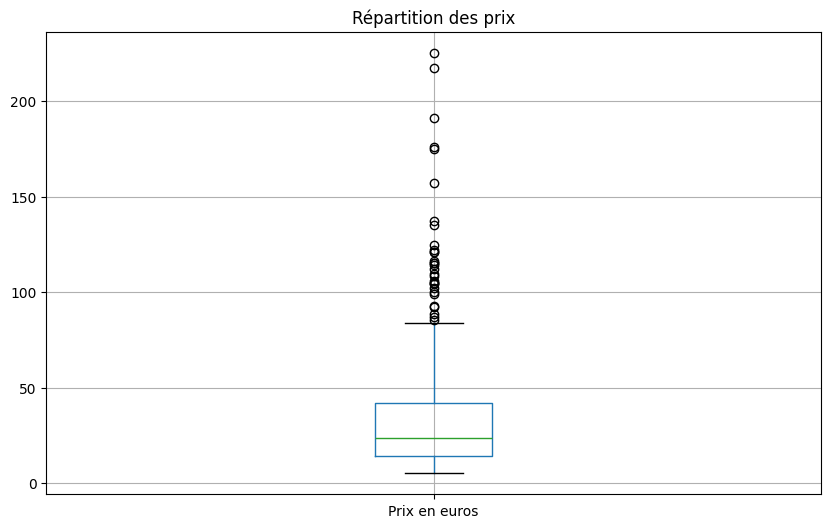

In [445]:
#Création d'une boîte à moustache de la répartition des prix grâce à Pandas
fig=df_merge.boxplot(column='price', figsize=(10,6))
fig.set_title('Répartition des prix')

# Sert à modifier le label automatique en le supprimant dans un premier temps puis le remplaçant
fig.set_xlabel('')
fig.set_xticklabels(['Prix en euros'])

plt.show()

In [446]:
#Autre méthode avec plotly express
fig = px.box(df_merge, x='price', hover_name='post_name', labels={'price':'Prix en euros'})
fig.update_xaxes(showgrid=True, gridwidth=1, gridcolor='grey')
fig.update_layout(title_text='Répartition des prix',title_x=0.5)

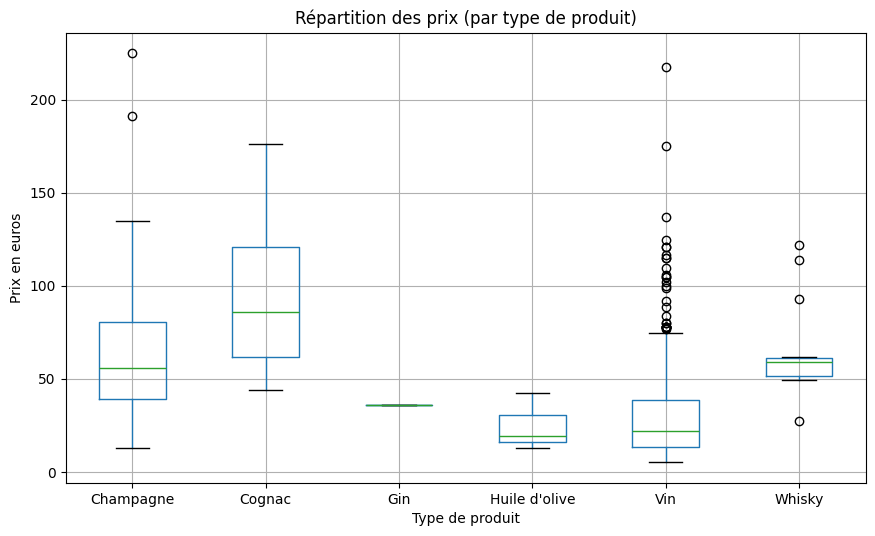

In [447]:
#Création d'une boîte à moustache de la répartition des prix grâce à Pandas
figure=df_merge.boxplot(column='price', by='product_type', figsize=(10,6))
figure.set_title('Répartition des prix (par type de produit)')
figure.set_xlabel('Type de produit')
figure.set_ylabel('Prix en euros')
plt.suptitle('') 
plt.show()

In [448]:
#Autre méthode avec plotly express
figure = px.box(df_merge, x='product_type', y='price', labels={'product_type':'Type de produit','price':'Prix en euros'}, 
                category_orders={'product_type': sorted(df_merge['product_type'].dropna().unique())})
figure.update_xaxes(showgrid=True, gridwidth=1, gridcolor='grey')
figure.update_yaxes(showgrid=True, gridwidth=1, gridcolor='grey')
figure.update_layout(title_text='Répartition des prix (par type de produit)',title_x=0.5)


In [449]:
fig = px.histogram(df_merge,
    x="total_sales",
    nbins=30,
    title="Répartition des ventes",
    color_discrete_sequence=["steelblue"],
    opacity=0.8
)

fig.add_vline(
    x=-0.5,
    line_width=2,
    line_dash="dash",
    line_color="red",
    annotation_text="Seuil 0",
    annotation_position="top left"
)

fig.update_layout(
    xaxis_title="Ventes",
    yaxis_title="Fréquence du nombre de ventes",
    width=900,
    height=500
)

fig.show()

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 4.2 - Exploration par l'utilisation de méthodes statistiques</h3>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 4.2.1 - Identification par le Z-index</h3>
</div>

In [450]:
df_merge.describe()

,product_id,onsale_web,price,stock_quantity,purchase_price,total_sales,post_date,post_modified_gmt
count,714.000000,714.000000,714.000000,714.000000,714.000000,714.000000,714,714
mean,5032.557423,0.997199,32.333683,23.443978,16.904006,8.054622,2018-08-22 03:57:52.950980608,2020-06-20 19:51:53.929971968
min,3847.000000,0.000000,5.200000,-1.000000,2.740000,0.000000,2018-02-08 12:58:52,2018-02-20 14:19:23
25%,4280.250000,1.000000,14.062500,9.000000,7.240000,5.000000,2018-02-27 20:01:12.500000,2020-06-18 16:32:35
50%,4796.000000,1.000000,23.450000,20.000000,12.305000,8.000000,2018-04-19 14:52:10,2020-08-04 07:30:06.500000
75%,5710.500000,1.000000,42.075000,30.000000,22.030000,11.000000,2019-01-31 14:35:47,2020-08-25 08:32:32
max,7338.000000,1.000000,225.000000,145.000000,137.810000,36.000000,2020-07-20 11:00:00,2020-08-27 16:55:03
std,790.510878,0.052888,27.596332,22.220755,14.827384,4.161344,NaN,NaN


In [451]:
#Calculer la moyenne du prix : 
moyenne=round(df_merge['price'].mean(),2)
print(f'La moyenne de prix est de {moyenne} €')

#Calculer l'écart-type du prix : 
ecart_type=round(df_merge['price'].std(),2)
print(f'L\'ecart-type de prix est de {ecart_type} €')

#Calculer le Z-score : 
z_score=round(moyenne/ecart_type,2)

print(f'Le Z-score de prix est de {z_score}.\n Le Zscore inférieur à 2 est considéré comme un écart par rapport à la moyenne, tout à fait normal.')

# Ecart_type par rapport à la moyenne : coefficient de variation
coeff_variation=round(ecart_type/moyenne,2)
print(f'Le coefficient de variance est de {coeff_variation}')


La moyenne de prix est de 32.33 €
L'ecart-type de prix est de 27.6 €
Le Z-score de prix est de 1.17.
 Le Zscore inférieur à 2 est considéré comme un écart par rapport à la moyenne, tout à fait normal.
Le coefficient de variance est de 0.85


In [452]:
#Quel est le seuil prix dont le z-score est supérieur à 3?
# Ici on va créer une colonne pour indiquer le Z-score de chaque prix
df_merge['z_score'] = (df_merge['price'] - df_merge['price'].mean()) / df_merge['price'].std()
seuilmin = df_merge.loc[df_merge['z_score'] > 3, 'price'].min()
print(f'Le seuil de prix dont le Z-score est strictement supérieur à 3 est de : {seuilmin}')

Le seuil de prix dont le Z-score est strictement supérieur à 3 est de : 116.4


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 4.2.2 - Identification par l'intervalle interquartile</h3>
</div>

In [453]:
#Utilisation de la fonction "describe" de Pandas pour l'étude des mesures de dispersion
df_merge.describe()

,product_id,onsale_web,price,stock_quantity,purchase_price,total_sales,post_date,post_modified_gmt,z_score
count,714.000000,714.000000,714.000000,714.000000,714.000000,714.000000,714,714,7.140000e+02
mean,5032.557423,0.997199,32.333683,23.443978,16.904006,8.054622,2018-08-22 03:57:52.950980608,2020-06-20 19:51:53.929971968,-3.980632e-17
min,3847.000000,0.000000,5.200000,-1.000000,2.740000,0.000000,2018-02-08 12:58:52,2018-02-20 14:19:23,-9.832351e-01
25%,4280.250000,1.000000,14.062500,9.000000,7.240000,5.000000,2018-02-27 20:01:12.500000,2020-06-18 16:32:35,-6.620874e-01
50%,4796.000000,1.000000,23.450000,20.000000,12.305000,8.000000,2018-04-19 14:52:10,2020-08-04 07:30:06.500000,-3.219154e-01
75%,5710.500000,1.000000,42.075000,30.000000,22.030000,11.000000,2019-01-31 14:35:47,2020-08-25 08:32:32,3.529932e-01
max,7338.000000,1.000000,225.000000,145.000000,137.810000,36.000000,2020-07-20 11:00:00,2020-08-27 16:55:03,6.981591e+00
std,790.510878,0.052888,27.596332,22.220755,14.827384,4.161344,NaN,NaN,1.000000e+00


In [454]:
#Définir un seuil pour les articles "outliers" en prix :

#  SEUIL MINIMUM
# Cet indicateur est aussi utilisé dans l'identification des valeurs aberrantes par la règle donnée par John Tukey : 
# toute valeur de l'échantillon inférieure à Q1 - 1,5 EI est à considérer comme aberrante
q1=np.percentile(df_merge['price'],25)

out_q1=q1-(1.5*ecart_type)

#  SEUIL MAXIMUM
# Cet indicateur est aussi utilisé dans l'identification des valeurs aberrantes par la règle donnée par John Tukey : 
# toute valeur de l'échantillon supérieure à Q3 + 1,5 EI est à considérer comme aberrante

q3=np.percentile(df_merge['price'],75)

out_q3=q3+(1.5*ecart_type)


print(f'Le premier quartile est de : {q1}\n'
      f'L\'outlier premier quartile est de : {round(out_q1,2)}\n'
      f'Le troisième quartile est de : {q3}\n'
      f'L\'outlier du troisième quartile est de : {round(out_q3,2)}\n')

Le premier quartile est de : 14.0625
L'outlier premier quartile est de : -27.34
Le troisième quartile est de : 42.075
L'outlier du troisième quartile est de : 83.48



In [455]:
#Définir le nombre d'articles et la proportion de l'ensemble du catalogue "outliers"
nb_out_q3=(df_merge['price']>out_q3).sum()
nb_out_q1=(df_merge['price']<out_q1).sum()
nb_out=nb_out_q1+nb_out_q3
print(f'Le nombre d\'articles "outliers" est de : {nb_out}')

Le nombre d'articles "outliers" est de : 32


In [456]:
#Selon vous, ces outliers sont-ils justifiés ? 
# Comment le démontrer si cela est possible ?
df_outliers=df_merge[(df_merge['price']<out_q1)|(df_merge['price']>out_q3)]
df_outliers=df_outliers.sort_values('price', ascending=True)
display(df_outliers.head())
print('Il ressort de ce tableau que les prix considérés comme "outliers" sont en réalité des gammes plus élevées de produits')

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,_merge,sku,total_sales,tax_status,post_date,product_type,post_title,post_name,post_modified_gmt,post_type,z_score
506,5580,1,83.7,4,instock,41.08,both,13982,2.0,taxable,2018-11-26 15:19:55,Vin,Lucien Boillot Puligny-Montrachet 1er Cru Les ...,lucien-boillot-puligny-montrachet-1er-cru-les-...,2020-07-21 16:15:02,product,1.861346
205,4359,1,85.6,112,instock,51.93,both,13853,7.0,taxable,2018-03-02 11:11:48,Champagne,Champagne Larmandier-Bernier Grand Cru Les Che...,champagne-larmandier-bernier-grand-cru-vieille...,2019-12-23 08:30:11,product,1.930195
438,5026,1,86.8,101,instock,50.13,both,13913,9.0,taxable,2018-07-18 10:46:30,Champagne,Champagne Agrapart &amp; Fils Minéral Extra Br...,champagne-agrapart-fils-mineral-extra-brut-bla...,2020-05-11 12:35:02,product,1.973680
65,4132,1,88.4,7,instock,44.30,both,11668,5.0,taxable,2018-02-13 11:43:55,Vin,Zind-Humbrecht Pinot Gris Grand Cru Rangen De ...,zind-humbrecht-pinot-gris-grand-cru-rangen-de-...,2020-02-20 08:55:02,product,2.031658
502,5565,1,92.0,0,outofstock,46.11,both,19822,1.0,taxable,2018-11-26 10:59:10,Vin,Tempier Bandol Cabassaou 2017,tempier-bandol-cabassaou-2017,2020-01-04 12:57:04,product,2.162110


Il ressort de ce tableau que les prix considérés comme "outliers" sont en réalité des gammes plus élevées de produits


In [457]:
# Vérification du nombre d'articles situés entre les outliers
df_merge[(df_merge['price'] >= out_q1) & (df_merge['price'] <= out_q3)].value_counts().sum()

np.int64(681)

<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 5 - Analyse univariée du CA, des quantités vendues, des stocks et de la marge ainsi qu'une analyse multivariée  </h2>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.1 - Analyse des ventes en CA</h3>
</div>

In [458]:
############################# Travail sur df_merge #############################

#############################
# Calculer le CA du site web #
##############################

#Créer une colonne calculant le CA par article
df_merge['CA par article']=df_merge['price']*df_merge['total_sales']

#Calculer la somme de la colonne "ca_par_article"
ca_total=df_merge['CA par article'].sum()

#Ce résultat correspond au chiffre d'affaire du site web
print(f'Le chiffre d\'affaire du site Web est de : {ca_total:,.2f} €'.replace(",", " "))

Le chiffre d'affaire du site Web est de : 143 680.10 €


In [459]:
###############################
# Palmarès des articles en CA #
###############################

#Effectuer le tri dans l'ordre décroissant du CA du dataset df_merge
df_merge=df_merge.sort_values('CA par article', ascending=False)

#Réinitialiser l'index du dataset par un reset_index
df_merge.reset_index

#Afficher les 20 premiers articles en CA
df_merge.head(20)
#Graphique en barre des 20 premiers articles avec plotly express
df =df_merge.head(20).sort_values('CA par article', ascending=True)
palette = ["#9C8B83","#8B0000", "#D8D4A2"]

figure2 = px.bar(df, x='CA par article', y='post_title', color='product_type', 
                 labels={'post_title':"Article", 'CA par article':'Chiffre d\'affaire par article','product_type':'Type de produit'},
                 color_discrete_sequence=palette)
figure2.update_layout(title_text='Top 20 des articles en terme de CA',title_x=0.5)
figure2.update_yaxes(categoryorder='array', categoryarray=df['post_title'].tolist())
figure2.show()

In [460]:
#############################
# Calculer le 20 / 80 en CA #
#############################

#Créer une colonne calculant la part du CA de la ligne dans le dataset
df_merge['Part du CA']=round((df_merge['price']*df_merge['total_sales'])/ca_total*100,2)

#Créer une colonne réalisant la somme cumulative de la colonne précedemment créée : je vais donc classer par ordre décroissant (du plus contributif au moins contributif, au CA) 
    ### Puis je crée la colonne somme cumulée ligne 2 = cumul ligne 1 + 2 ; ligne 3 = cumul ligne 1 + 2 + 3 .... 
df_merge = df_merge.sort_values('Part du CA', ascending=False)

df_merge ['Somme cumulée'] = df_merge['Part du CA'].cumsum()

#Grâce aux deux colonnes créées précedemment, calculer le nombre d'articles représentant 80% du CA
art_80 = df_merge[df_merge['Somme cumulée'] <= 80]
nb_articles_80 = len(art_80)
print(f'Le nombre d\'articles représentant 80 % du CA est de : {nb_articles_80} articles')

#Afficher la proportion que représente ce groupe d'articles dans le catalogue entier du site web
prop_art=round(nb_articles_80/len(df_merge)*100,2)
print(f'La proportion que représente ce groupe d\'articles dans le catalogue entier du site web est de {prop_art} %')


Le nombre d'articles représentant 80 % du CA est de : 433 articles
La proportion que représente ce groupe d'articles dans le catalogue entier du site web est de 60.64 %


In [461]:
df_merge.head()

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,_merge,sku,total_sales,tax_status,post_date,product_type,post_title,post_name,post_modified_gmt,post_type,z_score,CA par article,Part du CA,Somme cumulée
199,4352,1,225.0,0,outofstock,137.81,both,15940,11.0,taxable,2018-03-02 10:30:04,Champagne,Champagne Egly-Ouriet Grand Cru Millésimé 2008,champagne-egly-ouriet-grand-cru-millesime-2008,2020-03-07 10:18:45,product,6.981591,2475.0,1.72,1.72
587,5892,1,191.3,98,instock,116.06,both,14983,6.0,taxable,2019-03-28 10:21:36,Champagne,Coteaux Champenois Egly-Ouriet Ambonnay Rouge ...,coteaux-champenois-egly-ouriet-ambonnay-rouge-...,2020-04-01 07:30:09,product,5.760415,1147.8,0.80,2.52
200,4353,1,79.5,127,instock,45.91,both,12587,14.0,taxable,2018-03-02 10:37:26,Champagne,Champagne Egly-Ouriet Grand Cru Brut Rosé,champagne-egly-ouriet-grand-cru-brut-rose,2020-08-22 09:45:02,product,1.709152,1113.0,0.77,3.29
582,5826,1,41.2,34,instock,21.71,both,15325,20.0,taxable,2019-03-27 17:59:49,Vin,Agnès Levet Côte Rôtie Améthyste 2017,agnes-levet-amethyste-2017,2020-05-21 12:00:02,product,0.321286,824.0,0.57,3.86
653,6212,1,115.0,16,instock,59.42,both,13996,7.0,taxable,2019-07-25 09:09:17,Vin,Domaine des Comtes Lafon Volnay 1er Cru Santen...,domaine-des-comtes-lafon-volnay-1er-cru-santen...,2020-06-16 07:30:16,product,2.995554,805.0,0.56,4.42


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.2 - Analyse des ventes en quantité</h3>
</div>

In [462]:
#####################################
# Palmarès des articles en quantité #
#####################################

#Effectuer le tri dans l'ordre décroissant de quantités vendues du dataset df_merge
df_merge=df_merge.sort_values('total_sales', ascending=False)

#Réinitialiser l'index du dataset par un reset_index
df_merge.reset_index

#Afficher les 20 premiers articles en quantité
df_merge.head(20)

#Graphique en barre des 20 premiers articles avec plotly express
df_nb_art =df_merge.head(20).sort_values('total_sales', ascending=True)

figure3 = px.bar(df_nb_art, x='total_sales', y='post_title', labels={'post_title':"Article", 'total_sales':'Nombre de d\'articles vendus'}, color_discrete_sequence=['#8B0000'])
figure3.update_layout(title_text='Top 20 des articles en terme de quantité',title_x=0.5)
figure3.show()

In [463]:
df_nb_art['total_sales'].sum()

np.float64(382.0)

In [464]:
df_merge['total_sales'].sum()

np.float64(5751.0)

In [465]:
df_merge.head()

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,_merge,sku,total_sales,tax_status,post_date,product_type,post_title,post_name,post_modified_gmt,post_type,z_score,CA par article,Part du CA,Somme cumulée
365,4867,1,9.9,121,instock,4.86,both,16148,36.0,taxable,2018-05-03 13:20:05,Vin,Château De La Selve IGP Coteaux de l'Ardèche M...,chateau-de-la-selve-igp-coteaux-de-lardeche-ma...,2020-08-27 07:30:15,product,-0.812923,356.4,0.25,22.82
122,4203,1,9.9,74,instock,5.01,both,15415,27.0,taxable,2018-02-15 14:33:42,Vin,Mas Laval IGP Pays d'Hérault Les Pampres Blanc...,mas-laval-igp-pays-herault-pampres-blanc-2018,2020-07-11 14:45:03,product,-0.812923,267.3,0.19,40.26
175,4275,1,14.9,62,instock,7.78,both,14864,24.0,taxable,2018-02-27 13:33:54,Vin,I Fabbri Chianti Classico Lamole 2017,i-fabbri-chianti-classico-lamole-2017,2020-08-22 12:35:02,product,-0.631739,357.6,0.25,21.57
321,4726,1,12.7,0,outofstock,6.82,both,14950,22.0,taxable,2018-04-18 11:53:51,Vin,François Baur Pinot Noir Schlittweg 2017,francois-baur-pinot-noir-schlittweg-2017,2020-05-06 09:35:01,product,-0.711460,279.4,0.19,36.84
265,4647,1,28.5,45,instock,14.14,both,16525,22.0,taxable,2018-04-17 09:28:58,Vin,Bernard Baudry Chinon Rouge La Croix Boissée 2017,bernard-baudry-chinon-rouge-croix-boissee-2017,2020-07-31 07:31:39,product,-0.138920,627.0,0.44,8.22


In [466]:
#############################
# Calculer le 20 / 80 en CA #
#############################

#Créer une colonne calculant la part en quantité de la ligne dans le dataset
df_merge['Part en quantité']=round((df_merge['total_sales']/df_merge['total_sales'].sum())*100,2)

# #Créer une colonne réalisant la somme cumulative de la colonne précedemment créée : je vais donc classer par ordre décroissant (du plus contributif au moins contributif, au CA) 
#     ### Puis je crée la colonne somme cumulée ligne 2 = cumul ligne 1 + 2 ; ligne 3 = cumul ligne 1 + 2 + 3 .... 
df_merge = df_merge.sort_values('Part en quantité', ascending=False)

df_merge ['Quantité cumulée'] = df_merge['Part en quantité'].cumsum()

#Grâce aux deux colonnes créées précedemment, calculer le nombre d'articles représentant 80% des ventes en quantité
qtt_art_80 = df_merge[df_merge['Quantité cumulée'] <= 80]
nb_qtt_art_80 = len(qtt_art_80)
print(f'Le nombre d\'articles représentant 80% des ventes en quantité est de : {nb_qtt_art_80} articles')

# #Afficher la proportion que représente ce groupe d'articles dans le catalogue entier du site web
prop_qtt_art=round(nb_qtt_art_80/len(df_merge)*100,2)
print(f'La proportion que représente ce groupe d\'articles dans le catalogue entier du site web est de {prop_qtt_art} %')


Le nombre d'articles représentant 80% des ventes en quantité est de : 432 articles
La proportion que représente ce groupe d'articles dans le catalogue entier du site web est de 60.5 %


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.3 - Analyse des stocks</h3>
</div>

In [467]:
df_merge.sort_values('stock_quantity', ascending=False)

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,_merge,sku,total_sales,tax_status,post_date,product_type,post_title,post_name,post_modified_gmt,post_type,z_score,CA par article,Part du CA,Somme cumulée,Part en quantité,Quantité cumulée
196,4337,1,83.0,145,instock,48.90,both,4679,0.0,taxable,2018-03-01 14:19:24,Champagne,Champagne Mailly Grand Cru Les Echansons 2007,champagne-mailly-grand-cru-les-echansons-2007,2020-07-08 15:35:03,product,1.835980,0.0,0.00,100.12,0.00,99.84
198,4350,1,79.5,145,instock,47.30,both,12588,7.0,taxable,2018-03-02 10:00:02,Champagne,Champagne Egly-Ouriet Grand Cru Extra Brut V.P.,champagne-egly-ouriet-extra-brut-vp,2020-08-27 09:45:02,product,1.709152,556.5,0.39,10.28,0.12,74.93
194,4334,1,49.0,142,instock,30.01,both,7818,7.0,taxable,2018-03-01 14:02:44,Champagne,Champagne Gosset Grand Blanc de Blancs,champagne-gosset-grand-blanc-de-blanc,2020-08-12 12:00:03,product,0.603932,343.0,0.24,26.23,0.12,81.53
642,6126,1,135.0,138,instock,80.33,both,14923,5.0,taxable,2019-06-28 17:22:27,Champagne,Champagne Gosset Célébris Vintage 2007,champagne-gosset-celebris-vintage-2007,2020-08-27 09:45:02,product,3.720288,675.0,0.47,6.43,0.09,89.42
437,5025,1,112.0,136,instock,68.60,both,13914,6.0,taxable,2018-07-18 10:39:43,Champagne,Champagne Agrapart &amp; Fils L'Avizoise Extra...,champagne-agrapart-fils-lavizoise-grand-cru-20...,2020-07-09 15:05:02,product,2.886844,672.0,0.47,6.90,0.10,83.29
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2,3850,1,20.8,0,outofstock,10.64,both,15300,0.0,taxable,2018-02-08 14:08:36,Vin,Pierre Jean Villa Crozes-Hermitage Accroche Co...,pierre-jean-villa-croze-hermitage-accroche-coe...,2020-06-26 16:15:03,product,-0.417943,0.0,0.00,100.12,0.00,99.84
118,4198,1,5.8,0,outofstock,2.97,both,16322,0.0,taxable,2018-02-15 13:51:32,Vin,Moulin de Gassac IGP Pays d'Hérault Guilhem Ro...,moulin-gassac-igp-pays-herault-guilhem-rouge-2019,2020-08-26 14:05:03,product,-0.961493,0.0,0.00,100.12,0.00,99.84
116,4196,1,27.2,0,outofstock,14.05,both,13032,0.0,taxable,2018-02-15 11:58:43,Vin,Château de La Liquière Faugères Tucade 2015,chateau-de-liquiere-faugeres-tucade-2015,2020-07-10 12:00:03,product,-0.186028,0.0,0.00,100.12,0.00,99.84
8,4043,1,60.0,0,outofstock,29.45,both,14980,0.0,taxable,2018-02-12 10:03:05,Vin,Pierre Gaillard Côte Rôtie Esprit de Blonde 2017,pierre-gaillard-cote-rotie-esprit-blond-2017,2020-08-24 12:00:03,product,1.002536,0.0,0.00,100.12,0.00,99.84


In [468]:
######################################
# Calculer le nombre de mois de stock #
######################################

#Import de numpy 
# -->> fait en initial

#Création de la colonne Rotation de stock
df_merge['rotation_stock']=df_merge['stock_quantity']/df_merge['total_sales']

#Remplacement des "inf" par 0
df_merge = df_merge.replace(np.inf, 0)
# df_merge = df_merge.fillna(0)
# df_merge.sort_values('Rotation de stock', ascending=False)
# #Effectuer le tri dans l'ordre décroissant du nombre de mois de stock dans le dataset df_merge
df_merge=df_merge.sort_values('rotation_stock', ascending=False)

# #Graphique en barre du flop 20 des produits qui ont le plus de mois de stock
df_stock =df_merge.head(20).sort_values('rotation_stock', ascending=True)

palette = ["#9C8B83","#8B0000", "#D8D4A2"]

figure4 = px.bar(df_stock, x='rotation_stock', y='post_title', color='product_type', labels={'rotation_stock':'Nombre de mois de stock', 'post_title':"Article", 'product_type':'Type de produit'}, color_discrete_sequence=palette)
figure4.update_layout(title_text='Flop 20 des produits ayant le plus de mois de stock', title_x=0.5)

figure4.update_yaxes(categoryorder='array', categoryarray=df_stock['post_title'].tolist())

figure4.show()

In [469]:
print(f'La valeur représentée par le stock des produits du Flop20 est de {(df_stock['purchase_price']*df_stock['stock_quantity']).sum():,.2f} €'.replace(',',' '))
print(f'Le nombre de bouteilles en stock parmi les produits du Flop20 est de {df_stock['stock_quantity'].sum():,.0f} bouteilles'.replace(',',' '))

La valeur représentée par le stock des produits du Flop20 est de 87 108.25 €
Le nombre de bouteilles en stock parmi les produits du Flop20 est de 2 052 bouteilles


In [470]:
# Estimation de la valeur du stock des deux premiers du Flop 20
df_stock_2 =df_merge.head(2).sort_values('rotation_stock', ascending=True)
print(f'La valeur représentée par le stock des deux produits en tête du Flop20 est de {(df_stock_2['purchase_price']*df_stock_2['stock_quantity']).sum():,.2f} €'.replace(',',' '))

print(f'Le nombre de bouteilles en stock parmi les produits du Flop20 est de {df_stock_2['stock_quantity'].sum():,.0f} bouteilles'.replace(',',' '))

La valeur représentée par le stock des deux produits en tête du Flop20 est de 15 104.29 €
Le nombre de bouteilles en stock parmi les produits du Flop20 est de 263 bouteilles


In [471]:
df_stock_2.head()

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,_merge,sku,total_sales,tax_status,post_date,product_type,post_title,post_name,post_modified_gmt,post_type,z_score,CA par article,Part du CA,Somme cumulée,Part en quantité,Quantité cumulée,rotation_stock
642,6126,1,135.0,138,instock,80.33,both,14923,5.0,taxable,2019-06-28 17:22:27,Champagne,Champagne Gosset Célébris Vintage 2007,champagne-gosset-celebris-vintage-2007,2020-08-27 09:45:02,product,3.720288,675.0,0.47,6.43,0.09,89.42,27.60
70,4142,1,53.0,125,instock,32.15,both,11641,4.0,taxable,2018-02-13 13:08:44,Champagne,Champagne Gosset Grand Millésime 2006,champagne-gosset-grand-millesime-2006,2020-08-20 07:30:03,product,0.748879,212.0,0.15,55.96,0.07,96.73,31.25


In [472]:
####################################
# Valorisation des stocks en euros #
####################################

# (selon le prix de vente)
#Création de la colonne Valorisation des stocks en euros 
df_merge['Valorisation des stocks € (prix vente)'] = df_merge['stock_quantity'] * df_merge['purchase_price']

#Calculer la somme de la colonne "Valorisation_stock_euros"
valeur_stock_vente = df_merge['Valorisation des stocks € (prix vente)'].sum()

print(f'La valeur du stock selon le prix de vente est de {valeur_stock_vente:,.2f} €'.replace(',',' '))

La valeur du stock selon le prix de vente est de 277 305.77 €


In [473]:

# (selon le prix d'achat)
#Création de la colonne Valorisation des stocks en euros 
df_merge['Valorisation des stocks € (prix achat)'] = df_merge['stock_quantity'] * df_merge['price']

#Calculer la somme de la colonne "Valorisation_stock_euros"
valeur_stock_achat = df_merge['Valorisation des stocks € (prix achat)'].sum()

print(f'La valeur du stock selon le prix d\'achat est de {valeur_stock_achat:,.2f} €'.replace(',',' '))


La valeur du stock selon le prix d'achat est de 494 593.40 €


In [474]:
##############################################
# Valorisation du nombre de produits en stock #
##############################################

#Calculer la somme de la colonne stock quantity
stock_total=df_merge['stock_quantity'].sum()
print(f'La quantité de bouteilles en stock est de {stock_total:,.0f} bouteilles'.replace(',',' '))

La quantité de bouteilles en stock est de 16 739 bouteilles


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.4 - Analyse du taux de marge</h3>
</div>

In [475]:
############################
# Analyse du taux de marge #
############################

#Création de la colonne Prix HT
df_merge['prix_ht']=round((df_merge['price']/1.2),2)
#Création de la colonne Taux de marge
df_merge['taux_marge']=round((df_merge['prix_ht']-df_merge['purchase_price'])/df_merge['purchase_price']*100,2)
#Afficher le prix minimum de la colonne "taux_marge"
tx_marge_min=df_merge['taux_marge'].min()
print(f'Le taux de marge minimum est de : {tx_marge_min} %')
#Afficher le prix maximum de la colonne "taux_marge"
tx_marge_max=df_merge['taux_marge'].max()
print(f'Le taux de marge maximum est de : {tx_marge_max} %')

Le taux de marge minimum est de : -86.4 %
Le taux de marge maximum est de : 91.41 %


In [476]:
#Affichage de la ligne avec un taux de marge inférieur à 0
tx_negatif=df_merge[df_merge['taux_marge'] <= 0]

display(tx_negatif)

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,_merge,sku,total_sales,tax_status,post_date,product_type,post_title,post_name,post_modified_gmt,post_type,z_score,CA par article,Part du CA,Somme cumulée,Part en quantité,Quantité cumulée,rotation_stock,Valorisation des stocks € (prix vente),Valorisation des stocks € (prix achat),prix_ht,taux_marge
201,4355,1,12.65,97,instock,77.48,both,12589,0.0,taxable,2018-03-02 10:46:10,Champagne,Champagne Egly-Ouriet Grand Cru Blanc de Noirs,champagne-egly-ouriet-grand-cru-brut-blanc-de-...,2020-08-13 08:15:02,product,-0.713272,0.0,0.0,100.12,0.0,99.84,0.0,7515.56,1227.05,10.54,-86.4


In [477]:
#Création d'un dataframe avec les taux positifs
df_merge_copy=df_merge[df_merge['taux_marge'] >= 0]
#Afficher le prix minimum de la colonne "taux_marge"
tx_marge_min_copy=df_merge['taux_marge'].min()
print(f'Le taux de marge minimum est de : {tx_marge_min_copy} %')
#Afficher le prix maximum de la colonne "taux_marge"
tx_marge_max_copy=df_merge['taux_marge'].max()
print(f'Le taux de marge maximum est de : {tx_marge_max_copy} %')

Le taux de marge minimum est de : -86.4 %
Le taux de marge maximum est de : 91.41 %


In [478]:

pdt_marge_max = df_merge_copy[df_merge_copy['taux_marge'] == tx_marge_max_copy]
print('Le produit ayant le taux de marge maximum est :')
display(pdt_marge_max)

Le produit ayant le taux de marge maximum est :


,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,_merge,sku,total_sales,tax_status,post_date,product_type,post_title,post_name,post_modified_gmt,post_type,z_score,CA par article,Part du CA,Somme cumulée,Part en quantité,Quantité cumulée,rotation_stock,Valorisation des stocks € (prix vente),Valorisation des stocks € (prix achat),prix_ht,taux_marge
602,5916,1,93.0,1,instock,40.49,both,14774,1.0,taxable,2019-04-04 16:39:24,Whisky,Wemyss Malts Single Cask Scotch Whisky Chocola...,wemyss-malts-single-cask-chocolate-moka-cake,2019-12-23 08:30:21,product,2.198347,93.0,0.06,97.58,0.02,99.84,1.0,40.49,93.0,77.5,91.41


In [479]:
#Création d'un dataframe avec le taux de marge moyen par type de produit
df_tx_marge_moyen=df_merge_copy.groupby('product_type')['taux_marge'].mean().round(2).reset_index()
df_tx_marge_moyen=df_tx_marge_moyen.sort_values('taux_marge', ascending=True)
display(df_tx_marge_moyen)

#Affichage dans un graphique du taux de marge par type de produit
palette2= ["#97B68A","#D8D4A2","#8B0000", "#E0D5D0","#C4927C","#9C8B83"]
figure5=px.bar(df_tx_marge_moyen, x='taux_marge', y='product_type', color='product_type', labels={'taux_marge': 'Taux de marge', 'product_type':'Type de produit'}, color_discrete_sequence=palette2)
figure5.update_layout(title_text='Taux de marge par catégorie de produits',title_x=0.5)
figure5.show()

,product_type,taux_marge
3,Huile d'olive,33.41
0,Champagne,39.95
4,Vin,61.50
2,Gin,74.83
5,Whisky,81.74
1,Cognac,82.32


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.5 - Analyse des corrélations entre les variables stock, sales et price</h3>
</div>

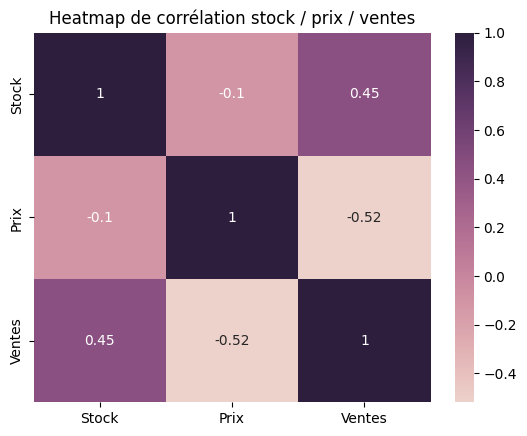

In [480]:
############################
# Analyse des corrélations #
############################

#Création d'une heatmap de corrélation avec les variables stock, sales et price
# plt.close('all')
corr = df_merge_copy[['stock_quantity','price','total_sales']].corr()
labels = ['Stock', 'Prix', 'Ventes']
sns.heatmap(corr, annot=True, cmap=sns.cubehelix_palette(as_cmap=True), xticklabels=labels,yticklabels=labels,)
plt.title('Heatmap de corrélation stock / prix / ventes')
plt.show()


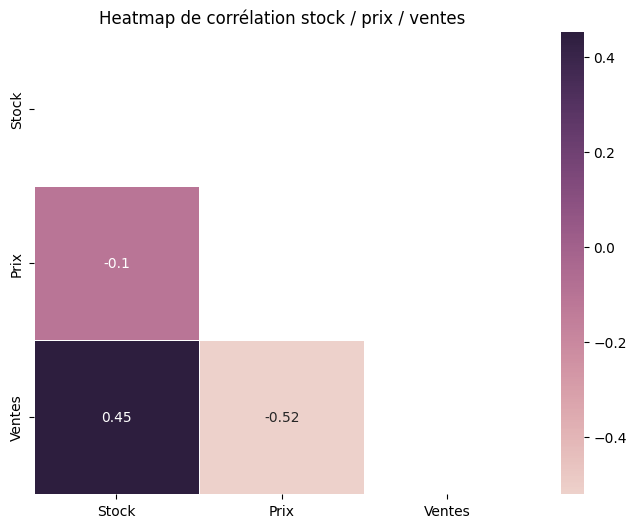

In [481]:
#On peut également créer un mask pour n'afficher qu'une demie heatmap
# Affichage de la moitié inférieure (avec mask de la moitié supérieure)
mask = np.triu(np.ones_like(corr, dtype=bool))

# Affichage de la heatmap masquée
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap=sns.cubehelix_palette(as_cmap=True), mask=mask, linewidths=0.5, xticklabels=labels, yticklabels=labels)
plt.title('Heatmap de corrélation stock / prix / ventes')
plt.show()


In [482]:
#Que peut-on conclure des corrélations ?
# stock_quantity et sales : +0.45 // Moyenne positive : plus de stock = plus de ventes (c'est logique) ​
# price et stock_quantity : -0.1 // Faible négative : prix légèrement plus bas =  stock plus élevé 
# price et total_sales : -0.52	// Négative modérée : plus le prix est bas → plus le chiffre d'affaire est élevé

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.6 - Mise à disposition de la nouvelle table sur un fichier Excel</h3>
</div>

In [483]:
#Mettre le dataset df_merge sur un fichier Excel
#Cette étape peut être utile pour partager le résultat du dataset obtenu avec les équipes.  
df_merge.to_csv('Fichier Bottleneck.xlsx', index=False)